<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
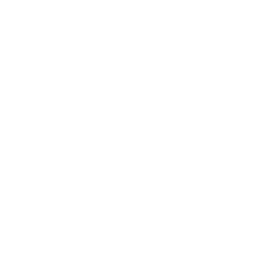
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Documentatie van het annotatieschema voor genomische varianten</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bio-informatica / Klinisch genomisch datamanagement &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Samenvatting

Documenteer het schema van VCF-achtige datasets met variantannotaties die in een klinische genomica-pijplijn worden gebruikt. Gebruik PROC CONTENTS om alle annotatievelden te catalogiseren — genomische coördinaten, allelfrequenties, voorspelde functionele effecten, ClinVar-classificaties en kwaliteitsmetrieken — zodat de downstream ACMG-tools voor variantinterpretatie correct getypeerde en gelabelde invoer ontvangen. Ongeveer 5.000 variantrecords met 20+ annotatiekolommen worden vóór de overdracht aan de pijplijn geïnspecteerd op schema-integriteit.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Uit VCF afgeleide geannoteerde varianten | ~5.000 |
| GENE_PANEL | Definities van het doelgenpanel | ~150 genen |
| QUALITY_METRICS | Sequencing-QC per sample | ~50 samples |

---

In [1]:
/* --------------------------------------------------------
   Genereer een VCF-achtige dataset met variantannotaties
   5.000 varianten met velden voor klinische annotatie
   -------------------------------------------------------- */
GEGEVENS variant_annotations;
    CALL streaminit(42);
    LENGTE variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    label variant_id='Variant-identificatie'
          chromosome='Chromosoom'
          position='Genomische positie (GRCh38)'
          ref_allele='Referentieallel'
          alt_allele='Alternatief allel'
          gene_symbol='HGNC-gensymbool'
          transcript_id='Ensembl-transcript-ID'
          consequence='Sequence Ontology-consequentie'
          impact='Voorspeld impactniveau'
          hgvs_c='HGVS-coderingsnotatie'
          hgvs_p='HGVS-eiwitnotatie'
          gnomad_af='gnomAD-allelfrequentie'
          clinvar_class='ClinVar-classificatie'
          clinvar_id='ClinVar-toegangsnummer'
          sift_score='SIFT-score'
          sift_pred='SIFT-voorspelling'
          polyphen_score='PolyPhen-2-score'
          polyphen_pred='PolyPhen-2-voorspelling'
          cadd_phred='CADD-Phred-score'
          revel_score='REVEL-ensemblescore'
          genotype='Sample-genotype'
          allele_depth='Diepte alternatief allel'
          read_depth='Totale leesdiepte'
          qual_score='Variantkwaliteitsscore'
          filter_status='Filterstatus';
    REEKS genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    REEKS conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    REEKS impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    REEKS cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    REEKS refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    REEKS gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    DOE i = 1 TOT 5000;
        variant_id = cat('VAR-', SCHRIJVEN(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SCHRIJVEN(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', SCHRIJVEN(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', SCHRIJVEN(codon_pos, 4.), ref_allele, '>', alt_allele);
        ALS c_idx <= 2 DAN
            hgvs_p = cat('p.', SCHRIJVEN(int(rand('uniform') * 800) + 1, 4.));
        ANDERS hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', SCHRIJVEN(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        ALS sift_score < 0.05 DAN sift_pred = 'DELETERIOUS';
        ANDERS sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        ALS polyphen_score > 0.908 DAN polyphen_pred = 'PROB_DAMAGING';
        ANDERS ALS polyphen_score > 0.446 DAN polyphen_pred = 'POSS_DAMAGING';
        ANDERS polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        UITVOER;
    EINDE;
    VERWIJDEREN i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
UITVOEREN;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.06 seconds
  cpu   3.06 seconds


In [2]:
/* --------------------------------------------------------
   Genereer de definities van het doelgenpanel
   -------------------------------------------------------- */
GEGEVENS gene_panel;
    CALL streaminit(42);
    LENGTE gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    label gene_symbol='HGNC-gensymbool'
          gene_name='Volledige gennaam'
          chromosome='Chromosoom'
          start_pos='Genstartpositie'
          end_pos='Geneindpositie'
          panel_name='Klinisch genpanel'
          disease_association='Geassocieerde ziekte'
          inheritance='Overervingspatroon';
    REEKS genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    REEKS gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    REEKS diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    REEKS inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    DOE g = 1 TOT 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', SCHRIJVEN(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        UITVOER;
    EINDE;
    VERWIJDEREN g chr_num;
UITVOEREN;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Genereer per sample de kwaliteitsmetrieken van de sequencing
   -------------------------------------------------------- */
GEGEVENS quality_metrics;
    CALL streaminit(42);
    LENGTE sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    label sample_id='Sample-identificatie'
          run_id='Sequencing-run-ID'
          platform='Sequencing-platform'
          mean_coverage='Gemiddelde doeldekking'
          pct_target_20x='Percentage basen >= 20x'
          pct_target_100x='Percentage basen >= 100x'
          total_variants='Totaal aantal gedetecteerde varianten'
          ti_tv_ratio='Transitie/transversie-ratio'
          het_hom_ratio='Het/hom-ratio'
          contamination_est='Geschatte contaminatie'
          qc_status='QC-status (geslaagd/mislukt)';
    DOE s = 1 TOT 50;
        sample_id = cat('SAMP-', SCHRIJVEN(s, z6.));
        run_id = cat('RUN-', SCHRIJVEN(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        ALS mean_coverage < 150 OR pct_target_20x < 95
            OR contamination_est > 0.015 DAN qc_status = 'FAIL';
        ANDERS qc_status = 'PASS';
        UITVOER;
    EINDE;
    VERWIJDEREN s;
UITVOEREN;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                        Variantimpact per ClinVar-classificatie                                         

                                                   The FREQ Procedure

Table of Voorspeld impactniveau by ClinVar-classificatie

Voorspeld impactniveau |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                   |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                       |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                       |                 14.52 |                 16.13 |     


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


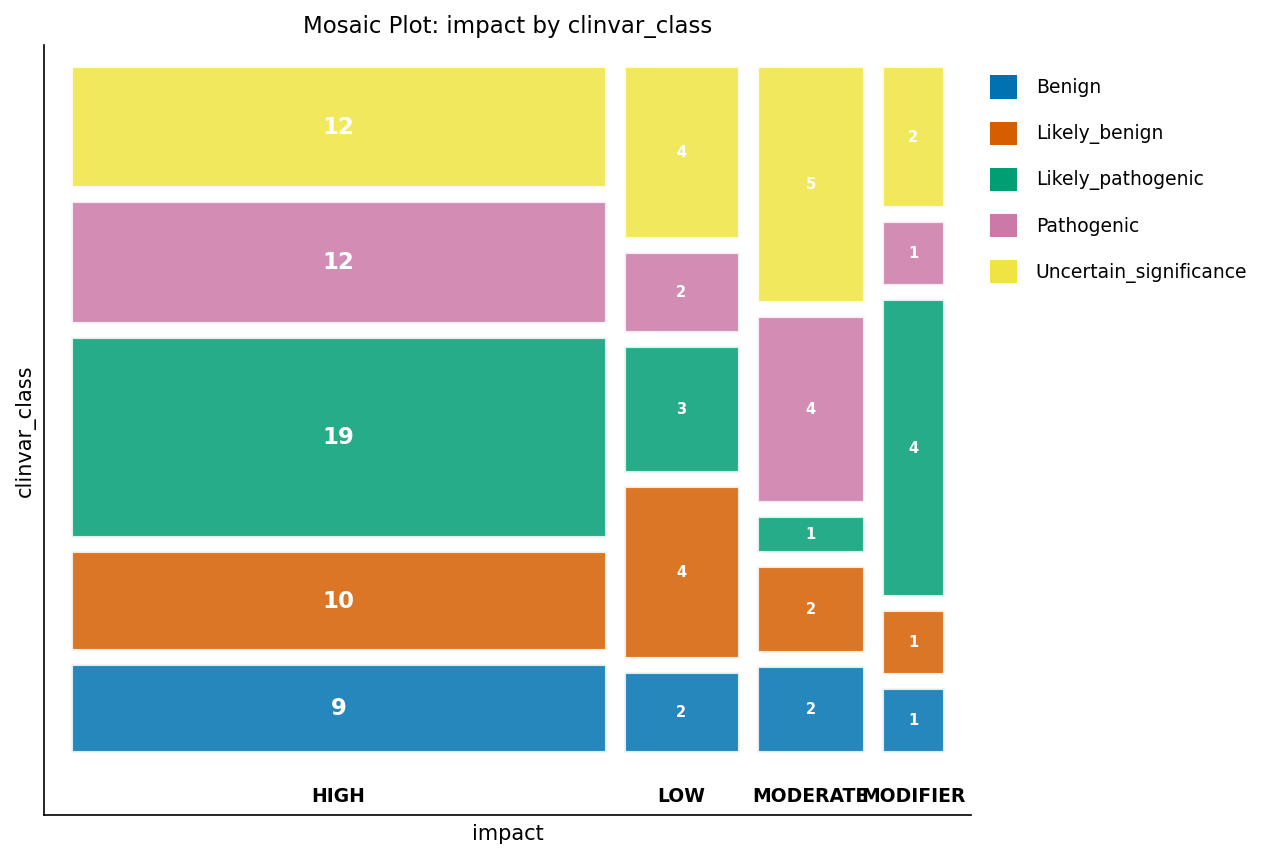

In [4]:
/* --------------------------------------------------------
   Basisoverzicht van de variantannotatie
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    label impact='Voorspeld impactniveau'
          clinvar_class='ClinVar-classificatie';
    TITEL 'Variantimpact per ClinVar-classificatie';
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=quality_metrics n mean MIN MAX;
    VARIABELE mean_coverage ti_tv_ratio contamination_est;
    label mean_coverage='Gemiddelde doeldekking'
          ti_tv_ratio='Transitie/transversie-ratio'
          contamination_est='Geschatte contaminatie';
    TITEL 'Samenvatting sequencing-kwaliteitsmetrieken';
UITVOEREN;

---

                                      Samenvatting sequencing-kwaliteitsmetrieken                                       

                                      Samenvatting sequencing-kwaliteitsmetrieken                                       




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


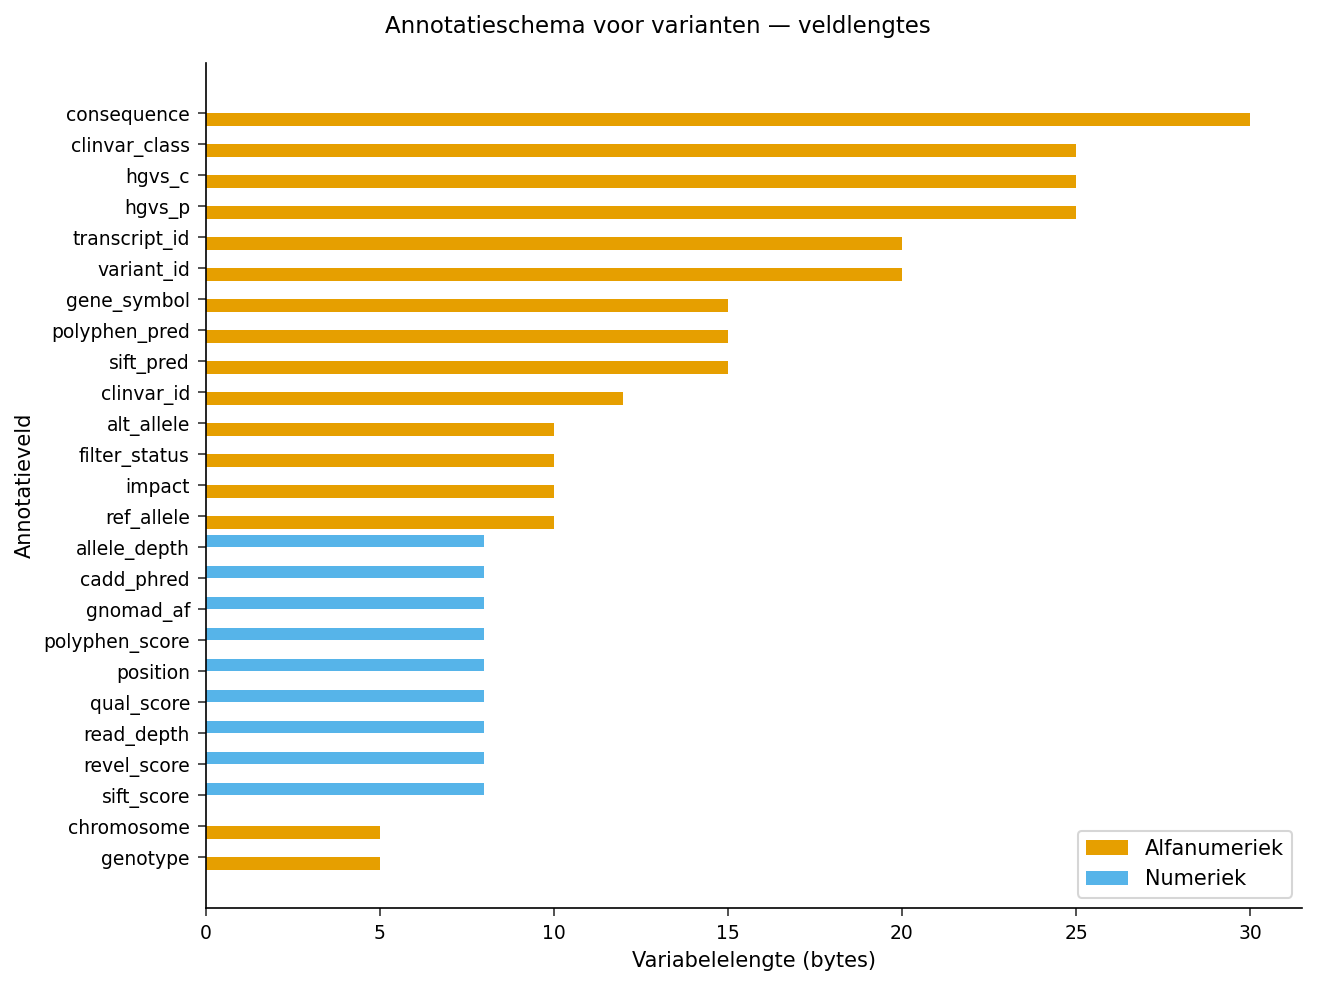

In [5]:
/* --------------------------------------------------------
   Verdeling van variabeletype en -lengte.
   Leg de metadata van het annotatieschema vast met PROC
   CONTENTS OUT= en plot vervolgens de veldlengtes per type.
   De TYPE-codes vertalen 1 -> Numeriek, 2 -> Alfanumeriek
   voor de legenda.
   -------------------------------------------------------- */
PROCEDURE INHOUD GEGEVENS=variant_annotations out=schema_lengths NOPRINT;
UITVOEREN;

GEGEVENS schema_lengths;
    INSTELLEN schema_lengths;
    LENGTE type_label $12;
    ALS TYPE = 1 DAN type_label = 'Numeriek';
    ANDERS type_label = 'Alfanumeriek';
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=schema_lengths;
    HBAR NAME / RESPONSE=LENGTE GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS label='Variabelelengte (bytes)';
    YAXIS label='Annotatieveld';
    TITEL 'Annotatieschema voor varianten — veldlengtes';
UITVOEREN;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: documenteer het volledige annotatieschema
   voor varianten — types, lengtes en labels voor alle 25
   velden. Leg de variabelemetadata vast met OUT= zodat
   vervolgstappen het schema programmatisch kunnen valideren.
   -------------------------------------------------------- */
PROCEDURE INHOUD GEGEVENS=variant_annotations out=variant_schema NOPRINT;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=variant_schema label;
    VARIABELE NAME TYPE LENGTE VARNUM LABEL;
    label NAME='Veldnaam' TYPE='Type' LENGTE='Lengte'
          VARNUM='Volgnummer' LABEL='Beschrijving';
    TITEL 'Dataset met variantannotaties — volledig schema';
UITVOEREN;

                                      Samenvatting sequencing-kwaliteitsmetrieken                                       

                                    Dataset met variantannotaties — volledig schema                                     

  Obs        Veldnaam  Type  Lengte  Volgnummer                    Beschrijving
    1  allele_depth       1       8          22  Diepte alternatief allel
    2  alt_allele         2      10           5  Alternatief allel
    3  cadd_phred         1       8          19  CADD-Phred-score
    4  chromosome         2       5           2  Chromosoom
    5  clinvar_class      2      25          13  ClinVar-classificatie
    6  clinvar_id         2      12          14  ClinVar-toegangsnummer
    7  consequence        2      30           8  Sequence Ontology-consequentie
    8  filter_status      2      10          25  Filterstatus
    9  gene_symbol        2      15           6  HGNC-gensymbool
   10  genotype           2       5          21  Sample-gen


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: documenteer het schema van het genpanel
   -------------------------------------------------------- */
PROCEDURE INHOUD GEGEVENS=gene_panel out=panel_schema NOPRINT;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=panel_schema label;
    VARIABELE NAME TYPE LENGTE VARNUM LABEL;
    label NAME='Veldnaam' TYPE='Type' LENGTE='Lengte'
          VARNUM='Volgnummer' LABEL='Beschrijving';
    TITEL 'Genpaneldefinitie — schema';
UITVOEREN;

                                    Dataset met variantannotaties — volledig schema                                     

                                               Genpaneldefinitie — schema                                               

  Obs             Veldnaam  Type  Lengte  Volgnummer          Beschrijving
    1  chromosome              2       5           3  Chromosoom
    2  disease_association     2      50           7  Geassocieerde ziekte
    3  end_pos                 1       8           5  Geneindpositie
    4  gene_name               2      60           2  Volledige gennaam
    5  gene_symbol             2      15           1  HGNC-gensymbool
    6  inheritance             2       5           8  Overervingspatroon
    7  panel_name              2      30           6  Klinisch genpanel
    8  start_pos               1       8           4  Genstartpositie




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: documenteer het schema van de QC-metrieken
   -------------------------------------------------------- */
PROCEDURE INHOUD GEGEVENS=quality_metrics out=qc_schema NOPRINT;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=qc_schema label;
    VARIABELE NAME TYPE LENGTE VARNUM LABEL;
    label NAME='Veldnaam' TYPE='Type' LENGTE='Lengte'
          VARNUM='Volgnummer' LABEL='Beschrijving';
    TITEL 'Sequencing-kwaliteitsmetrieken — schema';
UITVOEREN;

                                               Genpaneldefinitie — schema                                               

                                        Sequencing-kwaliteitsmetrieken — schema                                         

  Obs           Veldnaam  Type  Lengte  Volgnummer                           Beschrijving
    1  contamination_est     1       8          10  Geschatte contaminatie
    2  het_hom_ratio         1       8           9  Het/hom-ratio
    3  mean_coverage         1       8           4  Gemiddelde doeldekking
    4  pct_target_100x       1       8           6  Percentage basen >= 100x
    5  pct_target_20x        1       8           5  Percentage basen >= 20x
    6  platform              2      15           3  Sequencing-platform
    7  qc_status             2      10          11  QC-status (geslaagd/mislukt)
    8  run_id                2      12           2  Sequencing-run-ID
    9  sample_id             2      15           1  Sample-identificatie
 


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Schemavalidatie: controleer of de annotatievelden voldoen
   aan de pijplijnvereisten voor ACMG-interpretatie. Leest de
   PROC CONTENTS OUT=-metadata, waar TYPE=1 numeriek en
   TYPE=2 alfanumeriek aanduidt.
   -------------------------------------------------------- */
GEGEVENS schema_validation;
    INSTELLEN variant_schema;
    LENGTE requirement $60 status $10;
    /* Numerieke scorevelden moeten numeriek zijn (TYPE=1) */
    ALS NAME in ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 DAN DOE;
        requirement = 'Moet numeriek zijn voor score-drempels';
        status = 'MISLUKT';
    EINDE;
    ANDERS ALS NAME in ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 DAN DOE;
        requirement = 'Numeriek type bevestigd';
        status = 'GESLAAGD';
    EINDE;
    /* ClinVar-classificatie heeft voldoende tekenlengte nodig */
    ANDERS ALS NAME = 'clinvar_class' AND LENGTE < 25 DAN DOE;
        requirement = 'Min. $25 voor volledige classificatietekst';
        status = 'MISLUKT';
    EINDE;
    ANDERS ALS NAME = 'clinvar_class' DAN DOE;
        requirement = 'Tekenlengte voldoende';
        status = 'GESLAAGD';
    EINDE;
    /* Elk veld moet een label dragen voor het datawoordenboek */
    ANDERS ALS LABEL = '' DAN DOE;
        requirement = 'Label vereist voor datawoordenboek';
        status = 'MISLUKT';
    EINDE;
    ANDERS DOE;
        requirement = 'Algemene validatie';
        status = 'GESLAAGD';
    EINDE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=schema_validation label;
    VARIABELE NAME TYPE LENGTE LABEL requirement status;
    label NAME='Veldnaam' TYPE='Type' LENGTE='Lengte'
          LABEL='Beschrijving' requirement='Vereiste' status='Status';
    TITEL 'Schemavalidatierapport ACMG-pijplijn';
UITVOEREN;

                                          Schemavalidatierapport ACMG-pijplijn                                          

  Obs        Veldnaam  Type  Lengte                    Beschrijving                 Vereiste    Status
    1  allele_depth       1       8  Diepte alternatief allel        Numeriek type bevestigd  GESLAAGD
    2  alt_allele         2      10  Alternatief allel               Algemene validatie       GESLAAGD
    3  cadd_phred         1       8  CADD-Phred-score                Numeriek type bevestigd  GESLAAGD
    4  chromosome         2       5  Chromosoom                      Algemene validatie       GESLAAGD
    5  clinvar_class      2      25  ClinVar-classificatie           Tekenlengte voldoende    GESLAAGD
    6  clinvar_id         2      12  ClinVar-toegangsnummer          Algemene validatie       GESLAAGD
    7  consequence        2      30  Sequence Ontology-consequentie  Algemene validatie       GESLAAGD
    8  filter_status      2      10  Filterstatus     


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretatie

Het annotatieschema voor varianten bevat 25 velden die genomische coördinaten, functionele voorspellingen, populatiefrequenties en kwaliteitsindicatoren per sample omvatten. Alle negen numerieke scorevelden (gnomAD-allelfrequentie, SIFT, PolyPhen-2, CADD, REVEL, kwaliteitsscore, alleldiepte, leesdiepte en genomische positie) zijn correct als numeriek getypeerd, waardoor de ACMG-interpretatie-engine drempelgebaseerde filtering kan toepassen zonder typeconversie. Het veld clinvar_class op $25 biedt ruimte aan de langste ClinVar-classificatiestring (Uncertain_significance met 24 tekens). Elk annotatieveld draagt een beschrijvend label, wat voldoet aan het mandaat voor het datawoordenboek van het klinisch laboratorium onder de CAP-accreditatievereisten. Het genpanelschema brengt 15 kankerpredispositiegenen in kaart met overervingspatronen en ziekteassociaties, en biedt zo het referentiekader voor variant-naar-gen-annotatie. De dataset met sequencing-QC-metrieken documenteert 50 samples verdeeld over 5 runs, met contaminatieschattingen en dekkingsdrempels die de betrouwbaarheid van variant calling bepalen. Dit documentatiepakket voor het schema ondersteunt het validatiedossier van het laboratorium voor de indiening bij het New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Exporteer de schemadocumentatie van de varianten en het
   validatierapport voor de laboratoriumaccreditatie
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>